# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Juniyara Parisya Setiawan
- Email: parissajuniara@gmail.com
- Id Dicoding: juniyaraparisya

## Persiapan

### Menyiapkan library yang dibutuhkan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix
from xgboost import XGBClassifier


import joblib

### Menyiapkan data yang akan diguankan

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/dicodingacademy/dicoding_dataset/refs/heads/main/employee/employee_data.csv')

## Data Understanding

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmployeeId                1470 non-null   int64  
 1   Age                       1470 non-null   int64  
 2   Attrition                 1058 non-null   float64
 3   BusinessTravel            1470 non-null   object 
 4   DailyRate                 1470 non-null   int64  
 5   Department                1470 non-null   object 
 6   DistanceFromHome          1470 non-null   int64  
 7   Education                 1470 non-null   int64  
 8   EducationField            1470 non-null   object 
 9   EmployeeCount             1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   object 
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement            1470 non-null   int64  
 14  JobLevel

In [4]:
df.head(5)

,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,38,NaN,Travel_Frequently,1444,Human Resources,1,4,Other,1,...,2,80,1,7,2,3,6,2,1,2
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,...,1,80,0,15,2,1,1,0,0,0
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,...,3,80,3,18,2,4,10,0,2,7
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,...,4,80,1,23,2,4,20,4,4,8
4,5,40,NaN,Travel_Rarely,1194,Research & Development,2,4,Medical,1,...,2,80,3,20,2,3,5,3,0,2


In [5]:
df.isna().sum()

,0
EmployeeId,0
Age,0
Attrition,412
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

Tidak ada duplikat dalam data sehingga dapat dilakukan langkah selanjutnya.

In [8]:
df['Attrition'].fillna(2, inplace=True)
df['Attrition'] = df['Attrition'].astype(int)
df['Attrition'].value_counts()

/tmp/ipykernel_11377/2591320199.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Attrition'].fillna(2, inplace=True)


,count
Attrition,
0,879
2,412
1,179


In [9]:
df.isnull().sum()

,0
EmployeeId,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0


In [10]:
df.nunique()

,0
EmployeeId,1470
Age,43
Attrition,3
BusinessTravel,3
DailyRate,886
Department,3
DistanceFromHome,29
Education,5
EducationField,6
EmployeeCount,1


In [11]:
df.drop((['Over18', 'StandardHours', 'EmployeeCount']), axis = 1, inplace=True)

penghapusan data dilakukan karena tidak memiliki data yang berbeda atau unik, sehingga data tidak dapat mendapatkan pola untuk analisis.

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   EmployeeId                1470 non-null   int64 
 1   Age                       1470 non-null   int64 
 2   Attrition                 1470 non-null   int64 
 3   BusinessTravel            1470 non-null   object
 4   DailyRate                 1470 non-null   int64 
 5   Department                1470 non-null   object
 6   DistanceFromHome          1470 non-null   int64 
 7   Education                 1470 non-null   int64 
 8   EducationField            1470 non-null   object
 9   EnvironmentSatisfaction   1470 non-null   int64 
 10  Gender                    1470 non-null   object
 11  HourlyRate                1470 non-null   int64 
 12  JobInvolvement            1470 non-null   int64 
 13  JobLevel                  1470 non-null   int64 
 14  JobRole                 

In [13]:
df.describe()

,EmployeeId,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,735.500000,36.923810,0.682313,802.485714,9.192517,2.912925,2.721769,65.891156,2.729932,2.063946,...,3.153741,2.712245,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,424.496761,9.135373,0.881950,403.509100,8.106864,1.024165,1.093082,20.329428,0.711561,1.106940,...,0.360824,1.081209,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,1.000000,18.000000,0.000000,102.000000,1.000000,1.000000,1.000000,30.000000,1.000000,1.000000,...,3.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,368.250000,30.000000,0.000000,465.000000,2.000000,2.000000,2.000000,48.000000,2.000000,1.000000,...,3.000000,2.000000,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,735.500000,36.000000,0.000000,802.000000,7.000000,3.000000,3.000000,66.000000,3.000000,2.000000,...,3.000000,3.000000,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,1102.750000,43.000000,2.000000,1157.000000,14.000000,4.000000,4.000000,83.750000,3.000000,3.000000,...,3.000000,4.000000,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,1470.000000,60.000000,2.000000,1499.000000,29.000000,5.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,4.000000,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [14]:
df['Attrition'].value_counts(normalize=True)

,proportion
Attrition,
0,0.597959
2,0.280272
1,0.121769


<Axes: xlabel='Attrition'>

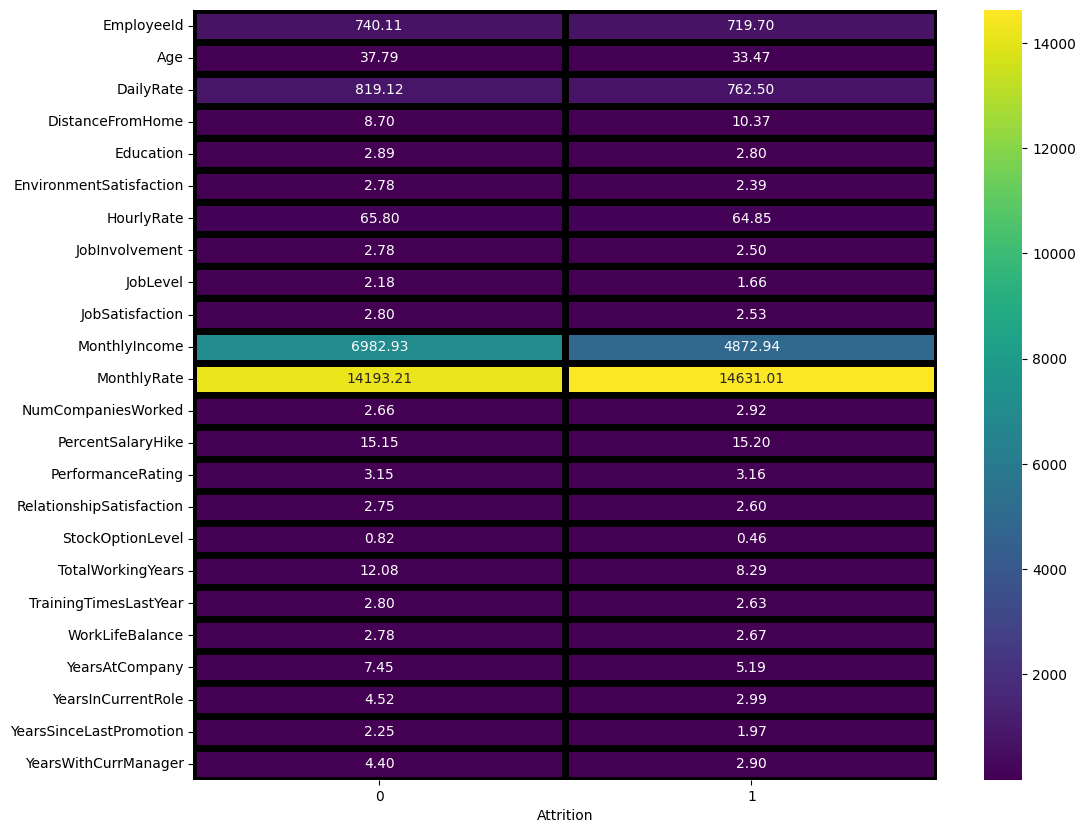

In [15]:
# Perbandingan data

num_feature = df[df['Attrition'] != 2].groupby('Attrition').mean(numeric_only = True)
Data_perbandingan = num_feature.T

plt.figure(figsize=(12, 10))
sns.heatmap(Data_perbandingan, annot = True, cmap='viridis', fmt='.2f',linewidths = 5, linecolor='black')

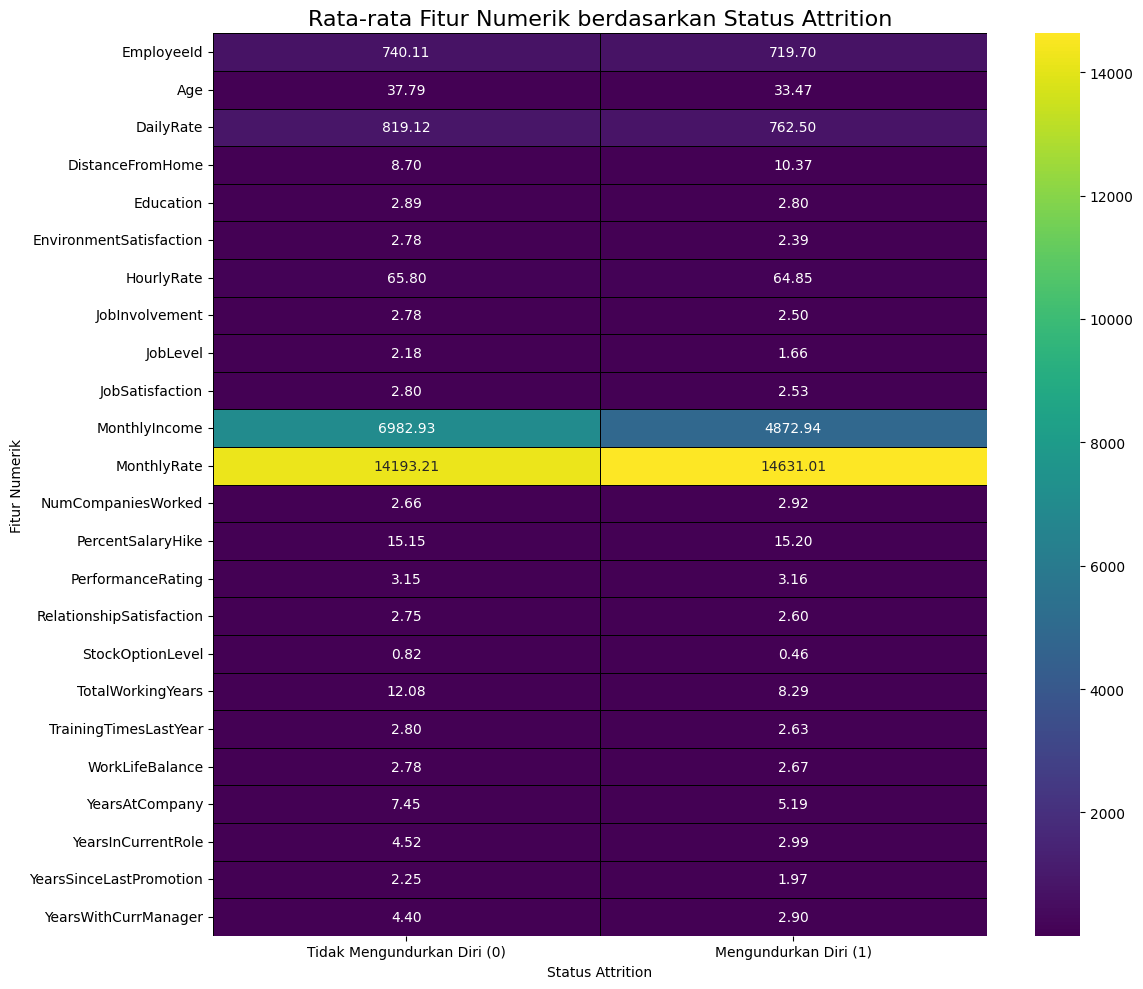

In [16]:
# First, ensure 'comparison_data' correctly contains only the mean of numeric features.
# Filter out Attrition = 2 (NaN values) for comparison between 0 and 1
comparison_data = df[df['Attrition'] != 2].groupby('Attrition').mean(numeric_only=True)

# We will transpose it so that features are rows and Attrition categories are columns for easier visualization.
heatmap_data_for_comparison = comparison_data.T

plt.figure(figsize=(12, 10))
sns.heatmap(heatmap_data_for_comparison, annot=True, cmap='viridis', fmt='.2f', linewidths=.5, linecolor='black')
plt.title('Rata-rata Fitur Numerik berdasarkan Status Attrition', fontsize=16)
plt.xlabel('Status Attrition')
plt.ylabel('Fitur Numerik')
plt.xticks(ticks=[0.5, 1.5], labels=['Tidak Mengundurkan Diri (0)', 'Mengundurkan Diri (1)'], rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

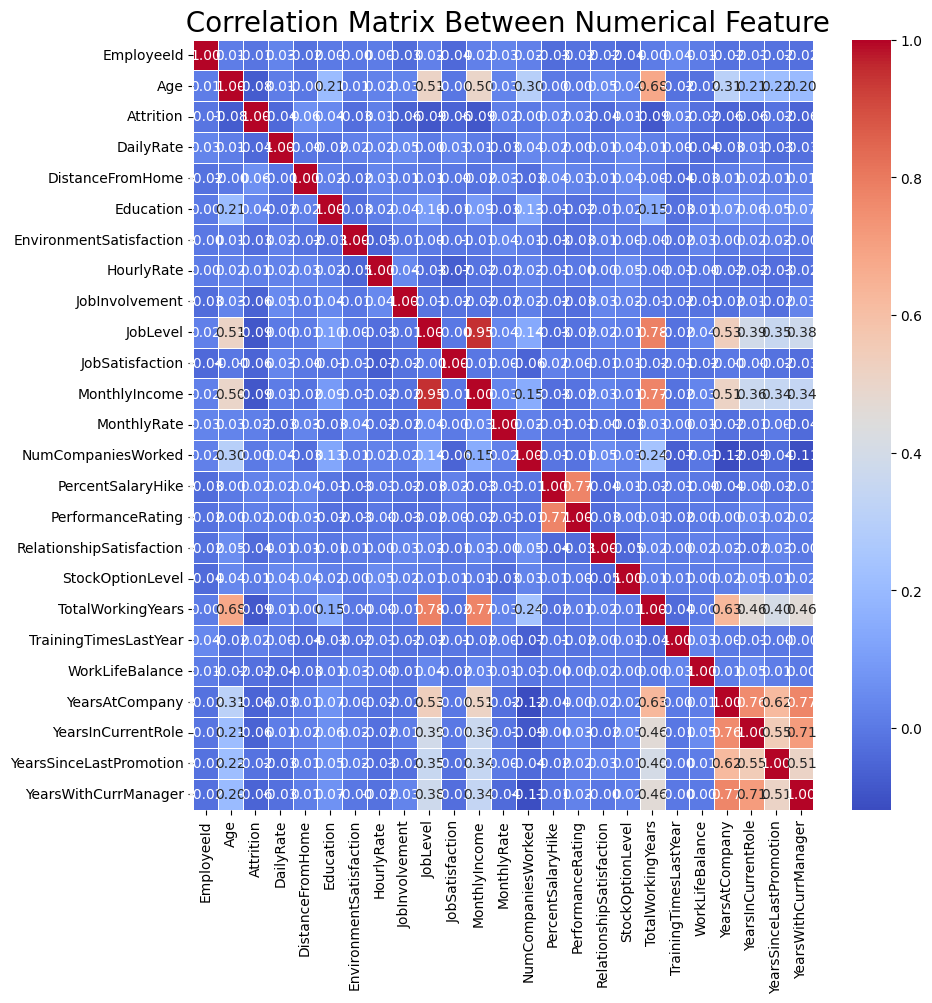

In [17]:
corr = df.corr(numeric_only = True)
plt.figure(figsize=(10, 10))
sns.heatmap(data=corr, annot=True, cmap='coolwarm', linewidths=0.5, fmt = ".2f")
plt.title(" Correlation Matrix Between Numerical Feature", size = 20)
plt.show()

dapat dilihat terdapat bola pada correlation matrix dimana korelasi diatas 0.7 merupakat pola untuk feature pada model, dimana pola yang dapat digunakan adalah
* ***PerformanceRating*** dengan ***PercentSalaryHike***,
* **JobLevel** dengan **TotalWorkingYears**
* **Joblevel** dengan **MontlyIncome**
* **YearsAtCompany** dengan **YearsInCurrentRole**
* **YearsAtCompany** dengan **YearsWitchCurrManager**
* **YearsInCurrentRole** dengan **YearsWitchCurrManager**


In [18]:
# Korelasi Attrion dengan Fitur Numerics

numerical_features = df.select_dtypes(include=np.number).columns
corr_matrix = df[numerical_features].corr().abs()
corr_attrion = corr_matrix['Attrition'].sort_values(ascending=False)
corr_attrion

,Attrition
Attrition,1.000000
MonthlyIncome,0.090509
JobLevel,0.089348
TotalWorkingYears,0.085851
Age,0.075837
DistanceFromHome,0.063210
YearsInCurrentRole,0.061554
JobInvolvement,0.060877
JobSatisfaction,0.056520
YearsWithCurrManager,0.056351


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   EmployeeId                1470 non-null   int64 
 1   Age                       1470 non-null   int64 
 2   Attrition                 1470 non-null   int64 
 3   BusinessTravel            1470 non-null   object
 4   DailyRate                 1470 non-null   int64 
 5   Department                1470 non-null   object
 6   DistanceFromHome          1470 non-null   int64 
 7   Education                 1470 non-null   int64 
 8   EducationField            1470 non-null   object
 9   EnvironmentSatisfaction   1470 non-null   int64 
 10  Gender                    1470 non-null   object
 11  HourlyRate                1470 non-null   int64 
 12  JobInvolvement            1470 non-null   int64 
 13  JobLevel                  1470 non-null   int64 
 14  JobRole                 

## Data Preparation / Preprocessing

In [20]:
median_attrition = df['Attrition'].median()
df['Attrition'].replace(2, median_attrition, inplace=True)

df['Attrition'] = df['Attrition'].astype(int)

print(df['Attrition'].value_counts())

Attrition
0    1291
1     179
Name: count, dtype: int64


/tmp/ipykernel_11377/334782906.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Attrition'].replace(2, median_attrition, inplace=True)


In [21]:
df.head()

,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,38,0,Travel_Frequently,1444,Human Resources,1,4,Other,4,...,3,2,1,7,2,3,6,2,1,2
1,2,37,1,Travel_Rarely,1141,Research & Development,11,2,Medical,1,...,3,1,0,15,2,1,1,0,0,0
2,3,51,1,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,...,3,3,3,18,2,4,10,0,2,7
3,4,42,0,Travel_Frequently,555,Sales,26,3,Marketing,3,...,3,4,1,23,2,4,20,4,4,8
4,5,40,0,Travel_Rarely,1194,Research & Development,2,4,Medical,3,...,3,2,3,20,2,3,5,3,0,2


In [22]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1176, 31), (294, 31), (1176,), (294,))

In [23]:
numerical_cols = ['Education', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobLevel',
                  'JobSatisfaction', 'NumCompaniesWorked', 'PercentSalaryHike',
                  'RelationshipSatisfaction', 'StockOptionLevel', 'TrainingTimesLastYear',
                  'WorkLifeBalance', 'YearsSinceLastPromotion',
                  'Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate', 'MonthlyIncome', 'MonthlyRate', 'TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager'
                  ]

categorical_cols = ['BusinessTravel', 'Department', 'EducationField', 'Gender',
                    'JobRole', 'MaritalStatus', 'OverTime']

numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

## Modeling

In [24]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_processed, y_train)

In [25]:
xgb_model = Pipeline(steps=[
    ('classifier', XGBClassifier())
])

param_space_xgb = {
    'classifier__n_estimators': [10, 20 ,50, 100],
    'classifier__max_depth': [3, 5, 7, 10],
    'classifier__gamma': [0.01, 0.1, 0.2, 0.3]
}

model_xgb = GridSearchCV(xgb_model, param_grid=param_space_xgb, cv=5)

model_xgb.fit(X_train_resampled, y_train_resampled)

print("Best Parameters:", model_xgb.best_params_)
print("Training Accuracy:", model_xgb.score(X_train_resampled, y_train_resampled))
print("Model Best Score (XGBoost):", model_xgb.best_score_)
print("Test Accuracy:", model_xgb.score(X_test_processed, y_test))

Best Parameters: {'classifier__gamma': 0.1, 'classifier__max_depth': 10, 'classifier__n_estimators': 20}
Training Accuracy: 1.0
Model Best Score (XGBoost): 0.9352270999286475
Test Accuracy: 0.8639455782312925


## Evaluation

In [26]:
y_pred_xgb = model_xgb.predict(X_test_processed)

print("\nConfusion Matrix XGBoost:")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nClassification Report XGBoost:")
print(classification_report(y_test, y_pred_xgb))


Confusion Matrix XGBoost:
[[251   7]
 [ 33   3]]

Classification Report XGBoost:
              precision    recall  f1-score   support

           0       0.88      0.97      0.93       258
           1       0.30      0.08      0.13        36

    accuracy                           0.86       294
   macro avg       0.59      0.53      0.53       294
weighted avg       0.81      0.86      0.83       294



In [27]:

y_pred_xgb = model_xgb.predict(X_test_processed)

print("\nConfusion Matrix XGBoost:")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nClassification Report XGBoost:")
print(classification_report(y_test, y_pred_xgb))


Confusion Matrix XGBoost:
[[251   7]
 [ 33   3]]

Classification Report XGBoost:
              precision    recall  f1-score   support

           0       0.88      0.97      0.93       258
           1       0.30      0.08      0.13        36

    accuracy                           0.86       294
   macro avg       0.59      0.53      0.53       294
weighted avg       0.81      0.86      0.83       294



In [28]:
df['Attrition'] = df['Attrition'].replace({0: 'Tidak Mengundurkan Diri',
                                           1: 'Mengundurkan Diri',
                                           2: 'tTidak Diketakui'})
display(df['Attrition'].head())

,Attrition
0,Tidak Mengundurkan Diri
1,Mengundurkan Diri
2,Mengundurkan Diri
3,Tidak Mengundurkan Diri
4,Tidak Mengundurkan Diri


In [29]:
joblib.dump(preprocessor, 'preprocessor.pkl')
joblib.dump(model_xgb, 'xgboost_model.pkl')

['xgboost_model.pkl']